# Similarity measures

## Set up working environment

In [68]:
import xml.etree.ElementTree as ET
import networkx as nx
import math

## Wordnet package

In [69]:
from nltk.corpus import wordnet as wn
import nltk 

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /home/mmathe/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/mmathe/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [70]:
# Look up a word using synsets() + optional pos argument to constrin the PoS word
wn.synsets("cat")

[Synset('cat.n.01'),
 Synset('guy.n.01'),
 Synset('cat.n.03'),
 Synset('kat.n.01'),
 Synset('cat-o'-nine-tails.n.01'),
 Synset('caterpillar.n.02'),
 Synset('big_cat.n.01'),
 Synset('computerized_tomography.n.01'),
 Synset('cat.v.01'),
 Synset('vomit.v.01')]

In [71]:
wn.synsets("cat", pos = wn.VERB)

[Synset('cat.v.01'), Synset('vomit.v.01')]

In [72]:
print(wn.synset("cat.n.01").definition())

feline mammal usually having thick soft fur and no ability to roar: domestic cats; wildcats


In [73]:
print(wn.synset("cat.n.01").lemmas())

[Lemma('cat.n.01.cat'), Lemma('cat.n.01.true_cat')]


In [74]:
wn.synset('cat.n.01').lowest_common_hypernyms(wn.synset('bird.n.01'))

[Synset('vertebrate.n.01')]

In [75]:
cat = wn.synset("cat.n.01")
bird = wn.synset("bird.n.01")
cat.path_similarity(bird)

0.14285714285714285

## Load MeSH thesaurus tree

In [76]:
# PARSE MESH THESAURUS TREE
G = nx.DiGraph()
name_to_trees = {}
tree_to_name  = {}

tree = ET.parse("/home/mmathe/Téléchargements/desc2026.xml")
root = tree.getroot()

for record in root.findall("DescriptorRecord"):
    name = record.findtext("DescriptorName/String")
    tree_numbers = [tn.text for tn in record.findall("TreeNumberList/TreeNumber")]

    name_to_trees[name] = tree_numbers
    for tn in tree_numbers:
        tree_to_name[tn] = name

        parts = tn.split(".")
        # Extract letter branch: "A05" -> letter="A", rest="05"
        letter = parts[0][0]        # "A"
        first  = parts[0]           # "A05"

        # ROOT -> A (branch letter)
        G.add_edge("ROOT", letter)
        # A -> A05
        G.add_edge(letter, first)

        # A05 -> A05.810 -> A05.810.453 ...
        for i in range(1, len(parts)):
            parent = ".".join(parts[:i])
            child  = ".".join(parts[:i+1])
            G.add_edge(parent, child)

depths = nx.single_source_shortest_path_length(G, "ROOT")

In [77]:
depths_by_name = {}
for name, trees in name_to_trees.items():
    if not trees:
        depths_by_name[name] = None
    else:
        depths_by_name[name] = max(depths.get(tn, 0) for tn in trees)

In [78]:
print(name_to_trees["Kidney"])
print(name_to_trees["Liver"])

['A05.810.453']
['A03.620']


## Path-based similarity measures

### Rada (1898)

R. Rada, H. Mili, E. Bicknell and M. Blettner, **Development and application of a metric on semantic networks** in IEEE Transactions on Systems, Man, and Cybernetics, vol. 19, no. 1, pp. 17-30, Jan.-Feb. 1989, doi: 10.1109/21.24528.  
Conceptual distance measure = length of the shortest path between 2 concepts in MeSH thesaurus using broader / narrower relations.  

In [79]:
def rada(mesh1, mesh2) :
    trees1 = name_to_trees.get(mesh1)
    trees2 = name_to_trees.get(mesh2)

    if not trees1:
        print(f"'{mesh1}' not found in MeSH")
        return None
    if not trees2:
        print(f"'{mesh2}' not found in MeSH")
        return None

    shortest = float("inf")
    for tn1 in trees1:
        for tn2 in trees2:
            try:
                d = nx.shortest_path_length(G.to_undirected(), tn1, tn2)
                shortest = min(shortest, d)
            except nx.NetworkXNoPath:
                continue

    return shortest if shortest < float("inf") else None

In [80]:
pairs = [
    ("Kidney", "Liver"),
    ("Kidney Diseases", "Liver Diseases"),
    ("Kidney", "Kidney Diseases"),
    ("Hypertension", "Diabetes Mellitus"),
    ("Kidney", "Bacteria"),
]

for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {rada(c1, c2)}")

Kidney                         <-> Liver                          : 5
Kidney Diseases                <-> Liver Diseases                 : 5
Kidney                         <-> Kidney Diseases                : 8
Hypertension                   <-> Diabetes Mellitus              : 5
Kidney                         <-> Bacteria                       : 6


### Caviedes and Cimino (2004)

Jorge E. Caviedes, James J. Cimino, **Towards the development of a conceptual distance metric for the UMLS**. Journal of Biomedical Informatics. Volume 37, Issue 2. 2004. Pages 77-85. ISSN 1532-0464. doi: https://doi.org/10.1016/j.jbi.2004.02.001.  
Same as Rada, but returns $\frac{1}{len(shortestPath(c_1, c_2))}$  
Values in $(0,1]$ : closer terms have a higher score (inverse of distance)

In [81]:
def caviedes_cimino(mesh1, mesh2) :
    if mesh1 == mesh2:
        return 1.0
    
    d = rada(mesh1, mesh2)

    if d is None or d == 0:
        return None
    
    return 1 / d

In [82]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {caviedes_cimino(c1, c2)}")

Kidney                         <-> Liver                          : 0.2
Kidney Diseases                <-> Liver Diseases                 : 0.2
Kidney                         <-> Kidney Diseases                : 0.125
Hypertension                   <-> Diabetes Mellitus              : 0.2
Kidney                         <-> Bacteria                       : 0.16666666666666666


In [83]:
# path similarity in wordnet
def get_best_path_similarity(mesh1, mesh2):
    """
    Compute the best path similarity between two terms
    by trying all synset combinations and taking the maximum.
    """
    synsets1 = wn.synsets(mesh1.replace(" ", "_"))
    synsets2 = wn.synsets(mesh2.replace(" ", "_"))

    if not synsets1:
        print(f"  No synsets found for: '{mesh1}'")
        return None
    if not synsets2:
        print(f"  No synsets found for: '{mesh2}'")
        return None

    best_score = 0
    best_pair = None

    for s1 in synsets1:
        for s2 in synsets2:
            score = s1.path_similarity(s2)
            if score is not None and score > best_score:
                best_score = score
                best_pair = (s1, s2)

    return best_score if best_score > 0 else None

In [84]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_best_path_similarity(c1, c2)}")

Kidney                         <-> Liver                          : 0.25
Kidney Diseases                <-> Liver Diseases                 : 0.14285714285714285
Kidney                         <-> Kidney Diseases                : 0.05263157894736842
Hypertension                   <-> Diabetes Mellitus              : 0.08333333333333333
Kidney                         <-> Bacteria                       : 0.07142857142857142


### Wu and Palmer (1994)

Zhibiao Wu and Martha Palmer. 1994. **Verb Semantics and Lexical Selection.** In 32nd Annual Meeting of the Association for Computational Linguistics, pages 133–138, Las Cruces, New Mexico, USA. Association for Computational Linguistics.  
Least Common Subsummer (LCS) = most specific concept 2 concepts share as an ancestor  
$Sim_{WP} = \frac{2 * depth(LCS(c_1, c_2))}{depth(c_1) + depth(c_2)}$

In [85]:
def mesh_depth(term):
    trees = name_to_trees.get(term)
    if not trees:
        print(f"'{term}' not found in MeSH")
        return None
    return max(depths.get(tn, 0) for tn in trees)

In [86]:
def lowest_common_subsumer(mesh1, mesh2):
    trees1 = name_to_trees.get(mesh1)
    trees2 = name_to_trees.get(mesh2)

    if not trees1:
        print(f"'{mesh1}' not found in MeSH")
        return None
    if not trees2:
        print(f"'{mesh2}' not found in MeSH")
        return None

    best_lcs  = None
    best_depth = -1

    for tn1 in trees1:
        for tn2 in trees2:
            ancestors1 = nx.ancestors(G, tn1) | {tn1}
            ancestors2 = nx.ancestors(G, tn2) | {tn2}
            common = ancestors1 & ancestors2
            if not common:
                continue

            lcs = max(common, key=lambda n: depths.get(n, 0))
            d   = depths.get(lcs, 0)
            if d > best_depth:
                best_depth = d
                best_lcs   = lcs

    # Return the term name if it exists, otherwise the tree number
    name = tree_to_name.get(best_lcs, best_lcs)
    return name, best_lcs

In [87]:
def wu_palmer(mesh1, mesh2) :
    d1 = mesh_depth(mesh1)
    d2 = mesh_depth(mesh2)
    lcs, lcs_tn = lowest_common_subsumer(mesh1, mesh2)
    dlcs = depths.get(lcs_tn)
    if dlcs is None or (d1 + d2) == 0:
        return None
    wp = (2 * dlcs) / (d1 + d2)
    return wp

In [88]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {wu_palmer(c1, c2)}")

Kidney                         <-> Liver                          : 0.2857142857142857
Kidney Diseases                <-> Liver Diseases                 : 0.2222222222222222
Kidney                         <-> Kidney Diseases                : 0.0
Hypertension                   <-> Diabetes Mellitus              : 0.2222222222222222
Kidney                         <-> Bacteria                       : 0.0


In [89]:
# wup similarity in wordnet
def get_wup_similarity(mesh1, mesh2):
    synsets1 = wn.synsets(mesh1.replace(" ", "_"))
    synsets2 = wn.synsets(mesh2.replace(" ", "_"))

    if not synsets1 or not synsets2:
        return None

    best_score = 0
    for s1 in synsets1:
        for s2 in synsets2:
            score = s1.wup_similarity(s2)
            if score is not None and score > best_score:
                best_score = score

    return best_score if best_score > 0 else None

In [90]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_wup_similarity(c1, c2)}")

Kidney                         <-> Liver                          : 0.8235294117647058
Kidney Diseases                <-> Liver Diseases                 : 0.7272727272727273
Kidney                         <-> Kidney Diseases                : 0.1
Hypertension                   <-> Diabetes Mellitus              : 0.5217391304347826
Kidney                         <-> Bacteria                       : 0.23529411764705882


### Leacock and Chodorov (1998)

Same as Wu and Palmer, but adds the depth of the taxonomy $D$  
$Sim_{LC} = - log(\frac{shortestPath(c_1, c_2)}{2D})$

In [91]:
max_depth = max(depths.values())
print(f"Max depth: {max_depth}")

Max depth: 14


In [92]:
def leacock_chodorow(mesh1, mesh2) :
    sp = rada(mesh1, mesh2)
    return -math.log(sp/(2*max_depth))

In [93]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {leacock_chodorow(c1, c2)}")

Kidney                         <-> Liver                          : 1.7227665977411035
Kidney Diseases                <-> Liver Diseases                 : 1.7227665977411035
Kidney                         <-> Kidney Diseases                : 1.252762968495368
Hypertension                   <-> Diabetes Mellitus              : 1.7227665977411035
Kidney                         <-> Bacteria                       : 1.540445040947149


In [94]:
# lch similarity in wordnet
def get_lch_similarity(mesh1, mesh2):
    synsets1 = wn.synsets(mesh1.replace(" ", "_"))
    synsets2 = wn.synsets(mesh2.replace(" ", "_"))

    if not synsets1 or not synsets2:
        return None

    best_score = 0
    for s1 in synsets1:
        for s2 in synsets2:
            if s1.pos() != s2.pos():   # ← skip mismatched POS
                continue
            score = s1.lch_similarity(s2)
            if score is not None and score > best_score:
                best_score = score

    return best_score if best_score > 0 else None

In [95]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_lch_similarity(c1, c2)}")

Kidney                         <-> Liver                          : 2.2512917986064953
Kidney Diseases                <-> Liver Diseases                 : 1.6916760106710724
Kidney                         <-> Kidney Diseases                : 0.6931471805599453
Hypertension                   <-> Diabetes Mellitus              : 1.1526795099383855
Kidney                         <-> Bacteria                       : 0.9985288301111273


### Nguyen and Al Mubaid (2006)

H. Al-Mubaid and H. A. Nguyen, "A Cluster-Based Approach for Semantic Similarity in the Biomedical Domain," 2006 International Conference of the IEEE Engineering in Medicine and Biology Society, New York, NY, USA, 2006, pp. 2713-2717, doi: 10.1109/IEMBS.2006.259235.  
Combine taxonomy depth + LCS  
$Sim_{NAM} = log (2 + (shortestPath(c_1, c_2) - 1) * (D - d))$ with $D$ as the depth of the taxonomy and $d$ as the depth of the LCS

In [96]:
def nguyen_almubaid(mesh1, mesh2) :
    sp = rada(mesh1, mesh2)
    lcs, lcs_tn = lowest_common_subsumer(mesh1, mesh2)
    dlcs = depths.get(lcs_tn)
    if dlcs is None :
        return None
    return math.log((2 + sp) * (max_depth - dlcs))

In [97]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {nguyen_almubaid(c1, c2)}")

Kidney                         <-> Liver                          : 4.51085950651685
Kidney Diseases                <-> Liver Diseases                 : 4.51085950651685
Kidney                         <-> Kidney Diseases                : 4.941642422609304
Hypertension                   <-> Diabetes Mellitus              : 4.51085950651685
Kidney                         <-> Bacteria                       : 4.718498871295094


## Information Content based similarity measures

**Information Content** : can be calculated using information derived from a corpus or information derived from a taxonomy   
  
- Corpus-based :  
IC = negative log of the probability of a concept   
$P(c*) = P(c) + \sum_{descendants(c) P(d)}$  
$P(d) = \frac{freq(d)}{N}$ with $freq(d)$ as the number of times the concept is seen in the corpus and $N$ as the total number of concepts  

- Taxonomy-based : assess the informativeness of a concept based on its placement within the hierarchy by looking at its incoming (ancestors) and outgoing (descendant) links  
$IC(c) = -log(\frac{\frac{|leaves(c)|}{|subsummers(c)|} + 1}{max_leaves + 1})$  

### Resnik (1995) 

Resnik, P. (1995). **Using information content to evaluate semantic similarity in a taxonomy.** arXiv preprint cmp-lg/9511007.  
Modified IC to be used as a similarity measure : similarity of 2 concepts = IC of their LCS  
$Sim_{Res} = IC(LCS(c_1, c_2)) = -log(P(LCS(c_1, c_2)))$  
--> Derive IC from the ontology structure, terms with fewer descendants are more specific and have a higher IC

In [98]:
def get_descendants(tn):
    """All descendant tree numbers of a given tree number."""
    return {n for n in G.nodes if n.startswith(tn + ".") or n == tn}

In [99]:
def compute_ic_structure():
    leaves = {n for n in G.nodes if G.out_degree(n) == 0}
    total_leaves = len(leaves)

    # Propagate leaves up to all ancestors once
    leaf_count = {n: set() for n in G.nodes}
    for leaf in leaves:
        for ancestor in nx.ancestors(G, leaf) | {leaf}:
            leaf_count[ancestor].add(leaf)

    ic = {}

    # IC for named descriptors
    for name, trees in name_to_trees.items():
        if not trees:
            continue
        best_ic = 0
        for tn in trees:
            term_leaves = leaf_count.get(tn, set())
            if not term_leaves:
                continue
            p = len(term_leaves) / total_leaves
            ic_val = -math.log(p) if p > 0 else 0
            best_ic = max(best_ic, ic_val)
        ic[name] = best_ic

    # IC for artificial branch nodes (A, B, C, ...)
    for node in G.nodes:
        if len(node) == 1 and node.isalpha():  # single letter = branch
            term_leaves = leaf_count.get(node, set())
            if term_leaves:
                p = len(term_leaves) / total_leaves
                ic[node] = -math.log(p) if p > 0 else 0

    # IC for ROOT = 0 by definition
    ic["ROOT"] = 0.0

    return ic

ic = compute_ic_structure()

In [100]:
def resnik(mesh1, mesh2):
    """Resnik similarity = IC of the Lowest Common Subsumer."""
    if mesh1 == mesh2 :
        return ic.get(mesh1, 0.0)

    lcs, lcs_tn = lowest_common_subsumer(mesh1, mesh2)

    if lcs_tn == "ROOT":
        return 0.0

    # Branch node (single letter) -> look up by tree number directly
    if len(lcs_tn) == 1:
        return ic.get(lcs_tn, 0.0)

    # Named descriptor -> look up by name
    return ic.get(lcs, 0.0)

In [101]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {resnik(c1, c2)}")

Kidney                         <-> Liver                          : 3.026722902717324
Kidney Diseases                <-> Liver Diseases                 : 1.6153855863577544
Kidney                         <-> Kidney Diseases                : 0.0
Hypertension                   <-> Diabetes Mellitus              : 1.6153855863577544
Kidney                         <-> Bacteria                       : 0.0


In [102]:
# resnik similarity with wordnet
from nltk.corpus import wordnet_ic
nltk.download('wordnet_ic') 
brown_ic = wordnet_ic.ic("ic-brown.dat")

[nltk_data] Downloading package wordnet_ic to
[nltk_data]     /home/mmathe/nltk_data...
[nltk_data]   Package wordnet_ic is already up-to-date!


In [103]:
def get_resnik_similarity(mesh1, mesh2):
    synsets1 = wn.synsets(mesh1.replace(" ", "_"))
    synsets2 = wn.synsets(mesh2.replace(" ", "_"))

    if not synsets1 or not synsets2:
        return None

    best_score = 0
    for s1 in synsets1:
        for s2 in synsets2:
            if s1.pos() != s2.pos():   
                continue
            score = s1.res_similarity(s2, brown_ic)
            if score is not None and score > best_score:
                best_score = score

    return best_score if best_score > 0 else None

In [104]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_resnik_similarity(c1, c2)}")

Kidney                         <-> Liver                          : 8.557516974893456
Kidney Diseases                <-> Liver Diseases                 : 6.715415750804551
Kidney                         <-> Kidney Diseases                : None
Hypertension                   <-> Diabetes Mellitus              : 6.015615471339601
Kidney                         <-> Bacteria                       : 0.8017591149538994


### Lin (1998)

Dekang Lin. 1998. **An Information-Theoretic Definition of Similarity.** In Proceedings of the Fifteenth International Conference on Machine Learning (ICML '98). Morgan Kaufmann Publishers Inc., San Francisco, CA, USA, 296–304.  
Add IC of the individual concepts, similar to Wu and Palmer, but using IC rather than the depth of concepts :  
$Sim_{Lin} = \frac{2 * IC(LCS(c_1, c_2))}{IC(c_1) + IC(c_2)}$

In [105]:
def lin(mesh1, mesh2) :
    if mesh1 == mesh2 :
        return ic.get(mesh1, 0.0)
    
    ic1 = ic.get(mesh1)
    ic2 = ic.get(mesh2)

    lcs, lcs_tn = lowest_common_subsumer(mesh1, mesh2)

    if lcs_tn == "ROOT":
        return 0.0

    # Branch node (single letter) -> look up by tree number directly
    if len(lcs_tn) == 1:
        iclcs = ic.get(lcs_tn, 0.0)
    
    return (2 * iclcs) / (ic1 + ic2)

In [106]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {lin(c1, c2)}")

Kidney                         <-> Liver                          : 0.33506599656721997
Kidney Diseases                <-> Liver Diseases                 : 0.24210349990232524
Kidney                         <-> Kidney Diseases                : 0.0
Hypertension                   <-> Diabetes Mellitus              : 0.18579364510307664
Kidney                         <-> Bacteria                       : 0.0


In [107]:
# lin similarity in wordnet
def get_lin_similarity(mesh1, mesh2):
    synsets1 = wn.synsets(mesh1.replace(" ", "_"))
    synsets2 = wn.synsets(mesh2.replace(" ", "_"))

    if not synsets1 or not synsets2:
        return None

    best_score = 0
    for s1 in synsets1:
        for s2 in synsets2:
            if s1.pos() != s2.pos():   
                continue
            score = s1.lin_similarity(s2, brown_ic)
            if score is not None and score > best_score:
                best_score = score

    return best_score if best_score > 0 else None

In [108]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_lin_similarity(c1, c2)}")

Kidney                         <-> Liver                          : 0.7183568199006088
Kidney Diseases                <-> Liver Diseases                 : 1.3430831501609101e-299
Kidney                         <-> Kidney Diseases                : None
Hypertension                   <-> Diabetes Mellitus              : 1.20312309426792e-299
Kidney                         <-> Bacteria                       : 0.07697062018760453


### Jiang and Conrath (1997)

Jiang, J.J., & Conrath, D.W. (1997). **Semantic Similarity Based on Corpus Statistics and Lexical Taxonomy.** ROCLING/IJCLCLP.  
Modified to return a similarity score by taking the reciprocal of the distance :  
$Sim_{JC} = \frac{1}{IC(c_1) + IC(c_2) - 2 * IC(LCS(c_1, c_2))}$

In [109]:
def jiang_conrath(mesh1, mesh2) :
    if mesh1 == mesh2 :
        return ic.get(mesh1, 0.0)
    
    ic1 = ic.get(mesh1)
    ic2 = ic.get(mesh2)

    lcs, lcs_tn = lowest_common_subsumer(mesh1, mesh2)

    if lcs_tn == "ROOT":
        return 0.0

    # Branch node (single letter) -> look up by tree number directly
    if len(lcs_tn) == 1:
        iclcs = ic.get(lcs_tn, 0.0)
    
    return 1 / ((ic1 + ic2) - (2 * iclcs))

In [110]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {jiang_conrath(c1, c2)}")

Kidney                         <-> Liver                          : 0.08324327449784931
Kidney Diseases                <-> Liver Diseases                 : 0.09887465179780926
Kidney                         <-> Kidney Diseases                : 0.0
Hypertension                   <-> Diabetes Mellitus              : 0.07063015647717187
Kidney                         <-> Bacteria                       : 0.0


In [111]:
# jiang conrath similarity with wordnet

def get_jcn_similarity(mesh1, mesh2):
    synsets1 = wn.synsets(mesh1.replace(" ", "_"))
    synsets2 = wn.synsets(mesh2.replace(" ", "_"))

    if not synsets1 or not synsets2:
        return None

    best_score = 0
    for s1 in synsets1:
        for s2 in synsets2:
            if s1.pos() != s2.pos():   
                continue
            score = s1.jcn_similarity(s2, brown_ic)
            if score is not None and score > best_score:
                best_score = score

    return best_score if best_score > 0 else None

In [112]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_jcn_similarity(c1, c2)}")

Kidney                         <-> Liver                          : 0.14902640152278462
Kidney Diseases                <-> Liver Diseases                 : 1e-300
Kidney                         <-> Kidney Diseases                : 1e-300
Hypertension                   <-> Diabetes Mellitus              : 1e-300
Kidney                         <-> Bacteria                       : 0.05200385749006155


## Relatedness measures

### Lesk (1986)

Michael Lesk. 1986. **Automatic sense disambiguation using machine readable dictionaries: how to tell a pine cone from an ice cream cone.** In Proceedings of the 5th annual international conference on Systems documentation (SIGDOC '86). Association for Computing Machinery, New York, NY, USA, 24–26. https://doi.org/10.1145/318723.318728  
Determine the relatedness between 2 concepts by counting the number of overlaps between their definitions.  
Overlap = longest sequence of consecutive words occuring in both definitions.  
--> Implemented in *Wordnet*

In [113]:
from nltk.wsd import lesk

Lesk algo doesn't return a similarity score directly --> picks the best matching synset for a given word. Adaptation : use each cpncept as context for the other, then get the disambiguated synsets and compute wup similariy

In [114]:
def get_lesk_similarity(mesh1, mesh2):
    # Use each term as context for the other
    synset1 = lesk(mesh1.split(), mesh1.split()[0])
    synset2 = lesk(mesh2.split(), mesh2.split()[0])

    if not synset1:
        print(f"  No synset found for: '{mesh1}'")
        return None
    if not synset2:
        print(f"  No synset found for: '{mesh2}'")
        return None

    print(f"  Synset 1: {synset1.name()} — {synset1.definition()}")
    print(f"  Synset 2: {synset2.name()} — {synset2.definition()}")

    # Once we have the disambiguated synsets, compute wup similarity ( = get a score between 0 and 1)
    score = synset1.wup_similarity(synset2)
    return score

In [115]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_lesk_similarity(c1, c2)}")

  Synset 1: kidney.n.01 — either of two bean-shaped excretory organs that filter wastes (especially urea) from the blood and excrete them and water in urine
  Synset 2: liver.n.01 — large and complicated reddish-brown glandular organ located in the upper right portion of the abdominal cavity; secretes bile and functions in metabolism of protein and carbohydrate and fat; synthesizes substances involved in the clotting of the blood; synthesizes vitamin A; detoxifies poisonous substances and breaks down worn-out erythrocytes
Kidney                         <-> Liver                          : 0.8235294117647058
  Synset 1: kidney.n.01 — either of two bean-shaped excretory organs that filter wastes (especially urea) from the blood and excrete them and water in urine
  Synset 2: liver.n.01 — large and complicated reddish-brown glandular organ located in the upper right portion of the abdominal cavity; secretes bile and functions in metabolism of protein and carbohydrate and fat; synthesizes 

### Liu (2012)

Ying Liu, Bridget T. McInnes, Ted Pedersen, Genevieve Melton-Meaux, and Serguei Pakhomov. 2012. Semantic relatedness study using second order co-occurrence vectors computed from biomedical corpora, UMLS and WordNet. In Proceedings of the 2nd ACM SIGHIT International Health Informatics Symposium (IHI '12). Association for Computing Machinery, New York, NY, USA, 363–372. https://doi.org/10.1145/2110363.2110405  
- Use second-order co-occurrence vectors  
- A vector is created for each word in the concepts definition containing words that co-occur with it in a corpus  
- These vectors are averaged to create a single co-occurrence vector for the concept  
- Similarity between concepts = cosine between second orders vectors

In [116]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

In [117]:
def get_extended_synonyms(mesh):
    synsets = wn.synsets(mesh.replace(" ", "_"))
    if not synsets:
        return ""
    
    syn_words = []
    s = synsets[0]  # use first (most common) sense
    
    # Own gloss
    syn_words.append(s.definition())
    
    # Related synsets: hypernyms, hyponyms, also_sees, etc.
    for related in s.hypernyms() + s.hyponyms() + s.also_sees():
        syn_words.append(related.definition())

    return " ".join(syn_words)

In [118]:
def get_sov_similarity(mesh1, mesh2):
    gloss1 = get_extended_synonyms(mesh1)
    gloss2 = get_extended_synonyms(mesh2)

    if not gloss1 or not gloss2:
        return None

    # Build co-occurrence vectors using TF as a proxy
    vectorizer = CountVectorizer().fit([gloss1, gloss2])
    vectors = vectorizer.transform([gloss1, gloss2]).toarray()

    score = cosine_similarity([vectors[0]], [vectors[1]])[0][0]
    return score

In [119]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_sov_similarity(c1, c2)}")

Kidney                         <-> Liver                          : 0.5143167692487138
Kidney Diseases                <-> Liver Diseases                 : 0.5794402645484684
Kidney                         <-> Kidney Diseases                : 0.34554737023254406
Hypertension                   <-> Diabetes Mellitus              : 0.4769585240283266
Kidney                         <-> Bacteria                       : 0.3924504313164433


/!\ the true Liu et al. method uses a biomedical corpus to build co-occurrence vectors, not just Wordnet glosses 

## FORVM edges as a proxy for similarity

### Check if SKOS:RELATED exists between 2 concepts

In [120]:
from SPARQLWrapper import SPARQLWrapper, JSON

In [121]:
# Define the endpoint URL
forvm_endpoint_url = "https://forum.semantic-metabolomics.fr/sparql/"

In [122]:
def get_forvm_relation(mesh1, mesh2) :   
 # Check if a skos:related relation exists between the 2 concepts
    query = f"""
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
    PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
    ASK {{
        ?mesh1 rdfs:label "{mesh1}"@en .
        ?mesh1 a meshv:TopicalDescriptor .
        ?mesh2 rdfs:label "{mesh2}"@en .
        ?mesh2 a meshv:TopicalDescriptor .
        ?mesh1 skos:related ?mesh2 .
    }}
    """

    # Initialise the SPARQL wrapper, submit the query, and request JSON back
    sparql = SPARQLWrapper(forvm_endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    result = sparql.query().convert()

    return result["boolean"]

In [123]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_forvm_relation(c1, c2)}")

Kidney                         <-> Liver                          : True
Kidney Diseases                <-> Liver Diseases                 : True
Kidney                         <-> Kidney Diseases                : True
Hypertension                   <-> Diabetes Mellitus              : True
Kidney                         <-> Bacteria                       : False


### Count number of shared descriptors

In [124]:
def get_forvm_shared(mesh1, mesh2) :   
 # Check if a skos:related relation exists between the 2 concepts
    query = f"""
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
    PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
    SELECT COUNT(DISTINCT ?shared) AS ?c
    WHERE {{
        ?mesh1 rdfs:label "{mesh1}"@en .
        ?mesh1 a meshv:TopicalDescriptor .
        ?mesh2 rdfs:label "{mesh2}"@en .
        ?mesh2 a meshv:TopicalDescriptor .
        ?shared skos:related ?mesh1 .
        ?shared skos:related ?mesh2 .
    }}
    """

    # Initialise the SPARQL wrapper, submit the query, and request JSON back
    sparql = SPARQLWrapper(forvm_endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    for result in results["results"]["bindings"] :
        return int(result["c"]["value"])


In [125]:
for c1, c2 in pairs:
    print(f"{c1:30s} <-> {c2:30s} : {get_forvm_shared(c1, c2)}")

Kidney                         <-> Liver                          : 932
Kidney Diseases                <-> Liver Diseases                 : 654
Kidney                         <-> Kidney Diseases                : 1454
Hypertension                   <-> Diabetes Mellitus              : 673
Kidney                         <-> Bacteria                       : 432


In [126]:
import pandas as pd

In [127]:
indexing_results_dataframe = pd.read_csv('indexing_results.tsv',sep = '\t')

In [128]:
indexing_results_dataframe_titles = pd.read_csv("indexing_results_titles.tsv", sep = "\t")

In [129]:
aop_wiki_results = pd.read_csv("ke_mesh_from_aopwiki.csv", sep = ",")
print(len(aop_wiki_results))

142


In [130]:
aop_mesh_mappings = pd.read_csv("aop_mesh_mappings.tsv", sep = "\t")

In [131]:
merged = aop_wiki_results.merge(aop_mesh_mappings, on=['KE_ID', 'MESH_ID'], how='left', indicator=True)
missing = merged[merged['_merge'] == 'left_only'][['KE_ID', 'MESH_ID']]

print(len(missing))

61


## Embeddings

https://github.com/helboukkouri/mesh-embeddings

In [132]:
import gzip
import pickle

with open('mesh_ui_to_id.pickle', 'rb') as stream:
    mesh_ui_to_id = pickle.load(stream)

embeddings = {}
with gzip.open('mesh_embeddings.txt.gz', 'rt') as stream:
    n_embeddings, embedding_dim = stream.readline().strip().split()
    for line in stream:
        splitline = str(line).strip().split()
        idx = int(splitline[0])
        vector = list(map(float, splitline[1:]))
        embeddings[idx] = vector

def get_embedding_from_mesh_ui(mesh_ui):
    idx = mesh_ui_to_id.get(mesh_ui)
    return embeddings[idx] if idx is not None else None

print(f'There are {n_embeddings} MeSH embeddings')
print(f'Each embedding is {embedding_dim}-dimensional')

print('MeSH UI for <Headache> is: D006261')
print('MeSH embedding for <Headache> is:', get_embedding_from_mesh_ui('D006261'))

There are 29638 MeSH embeddings
Each embedding is 256-dimensional
MeSH UI for <Headache> is: D006261
MeSH embedding for <Headache> is: [-0.22856602, -0.32223737, -0.16364807, 0.16428398, -0.12691289, 0.5625101, -0.17584483, -0.47571012, -0.088811584, 0.2617807, 0.05132794, 0.71627855, 0.43066362, -0.1670893, -0.26608157, -0.09317504, 0.14667332, -0.11840302, -0.1663675, -0.52484214, 0.14188018, -0.24755822, 0.17012611, 0.09081254, -0.12909845, -0.41837966, -0.6537568, 0.371565, 0.12833919, 0.005427597, 0.20416279, 0.08012802, 0.10650572, 0.07799014, 0.044482708, -0.017883368, -0.08914792, -0.16249849, 0.21305005, 0.30060294, -0.14664921, 0.2694519, -0.4759495, -0.42735684, 0.21831755, -0.0701913, -0.54911405, -0.1254092, 0.22662424, -0.06484091, -0.032748558, 0.4300212, -0.12393516, 0.46268645, 0.545198, 0.3075909, -0.44722748, 0.1205208, -0.59417015, 0.31570944, 0.4535999, -0.16720925, 0.1467588, -0.41351464, 0.052442025, 0.30475795, 0.22588854, -0.45776254, -0.21493755, 0.30782074, -

In [133]:
def cosine_similarity_1d(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(cosine_similarity_1d(get_embedding_from_mesh_ui("D050791"), get_embedding_from_mesh_ui("D050799")))

0.9649323950315064


In [134]:
print(cosine_similarity_1d(get_embedding_from_mesh_ui("D012756"), get_embedding_from_mesh_ui("D006801")))

0.4924096820741039


### Gale and Shapley

In [135]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def cosine_similarity_matrix(mesh_set_a, mesh_set_b):
    emb_a = [get_embedding_from_mesh_ui(ui) for ui in mesh_set_a]
    emb_b = [get_embedding_from_mesh_ui(ui) for ui in mesh_set_b]

    # Filter out None BEFORE converting to np.array
    emb_a = [e for e in emb_a if e is not None]
    emb_b = [e for e in emb_b if e is not None]

    if not emb_a or not emb_b:
        return np.array([])

    return cosine_similarity(np.array(emb_a), np.array(emb_b))

In [136]:
set_a = ['D006261', 'D001943']   # Headache, Breast Neoplasms
set_b = ['D006261', 'D009369']   # Headache, Neoplasms

sim_matrix = cosine_similarity_matrix(set_a, set_b)
print(sim_matrix)

[[1.         0.38293205]
 [0.36488883 0.64827016]]


In [137]:
def stableMarriage(baseline_mesh_set, pred_mesh_set):

    # SIMILARITY MATRIX
    # sim_matrix[i, j] = cosine similarity between baseline_mesh_set[i] and pred_mesh_set[j]
    # shape : (n, m)
    sim_matrix = cosine_similarity_matrix(baseline_mesh_set, pred_mesh_set)

    if sim_matrix.size == 0:
        return {}, list(baseline_mesh_set), list(pred_mesh_set)
     
    n = sim_matrix.shape[0]
    m = sim_matrix.shape[1]

    # PREFERENCE LISTS
    # prefs_baseline[a] : list of b indices sorted by decreasing similarity to a = the order in which a will "propose" to b
    # prefs_pred[b] : list of a indices sorted by decreasing similarity to b = b's preference ordering over a = used to decide to accept / reject "proposal"
    prefs_baseline = [list(np.argsort(row)[::-1]) for row in sim_matrix]
    prefs_pred     = [list(np.argsort(col)[::-1]) for col in sim_matrix.T]

    # rank_pred[b][a] = rank of a in b's preference list (mower = more preferred)
    # recomputed for O(1) lookup during the proposal loop, instead of scanning prefs_pred[b]
    rank_pred      = [{a: rank for rank, a in enumerate(prefs)} for prefs in prefs_pred]

    # INITIALISATION
    free_baseline  = list(range(n)) # all baseline items start unmatched and will propose
    next_prop      = [0] * n        # next_prop[a] = index of the next b to propose to in prefs_baseline[a]
    match_baseline = [None] * n     # match_baseline[a] = index of b currently matched to a (or None)
    match_pred     = [None] * m     # match_pred[b] = index of a currently matched to b (or None)

    # PROPOSAL LOOP : only for monogamy (low_threshold ≤ sim < high_threshold)
    # items with a high-threshold match are handled separately after
    while free_baseline :
        a = free_baseline.pop(0)    # pick any free baseline item to propose

        # if it has already proposed to every b and was rejected by all : stays unmatched
        if next_prop[a] >= len(prefs_baseline[a]) :
            # a has proposed to everyone and found no match → leave unmatched
            continue
        
        # a proposes to its most preferred b it hasn't proposed to yet
        b = prefs_baseline[a][next_prop[a]]
        next_prop[a] += 1   # a won't propose to b again regardless of outcome

        # if best remaining candidate is below threshold, a stays unmatched
        if sim_matrix[a, b] < 0.5 :
            continue

        # monogamy range : standard Gale Shapley algorithm    
        if match_pred[b] is None :
            # b is currently unmatched = b accepts unconditionnally
            match_baseline[a] = b
            match_pred[b] = a

        else :
            # b is already matched to a_current = b compares a and a_current
            a_current = match_pred[b]

            if rank_pred[b][a] < rank_pred[b][a_current] :
                # b prefers the new proposer a over its current partner = b swaps partner
                # but also check that a is good enough (similarity threshold)
                if sim_matrix[a, b] >= 0.5 :
                    match_baseline[a] = b
                    match_pred[b] = a
                    match_baseline[a_current] = None
                    free_baseline.append(a_current)
                else :
                    free_baseline.append(a)
            else :
                # b prefers its current partner = b rejects a
                free_baseline.append(a) # a remains free and will propose to its next candidate

    # POLYGAMY PASS : collect all b's above high_threshold for each a
    poly_matches = {
        a: [b for b in range(m) if sim_matrix[a, b] >= 0.9]
        for a in range(n)
    }

    # BUILD OUTPUT
    # Start from monogamy matches, then extend with poly matches
    matched = {}
    for a in range(n):
        partners = []

        # Add monogamy match if it exists
        if match_baseline[a] is not None:
            partners.append(pred_mesh_set[match_baseline[a]])

        # Add any high-similarity poly matches (avoid duplicating the monogamy match)
        for b in poly_matches[a]:
            pred_item = pred_mesh_set[b]
            if pred_item not in partners:
                partners.append(pred_item)

        if partners:
            matched[baseline_mesh_set[a]] = partners  # list of matched pred items

    unmatched_a = [baseline_mesh_set[a] for a in range(n) if not matched.get(baseline_mesh_set[a])]

    matched_bs = set(
        b for a in range(n)
        for b in ([match_baseline[a]] if match_baseline[a] is not None else []) + poly_matches[a]
    )
    unmatched_b = [pred_mesh_set[b] for b in range(m) if b not in matched_bs]

    return matched, unmatched_a, unmatched_b

In [138]:
set_a = ['D006261', 'D001943', 'D004715']   # Headache, Breast Neoplasms, Endometriosis
set_b = ['D006261', 'D009369']   # Headache, Neoplasms

matching, unmatched_a, unmatched_b = stableMarriage(set_a, set_b)

for a, bs in matching.items():
    for b in bs:
        print(f'{a} → {b}')
for a in unmatched_a:
    print(f'{a} → (unmatched)')
for b in unmatched_b:
    print(f'(unmatched) → {b}')

D006261 → D006261
D001943 → D009369
D004715 → (unmatched)


In [139]:
baseline = ["D002446", "D005983", "D006683", "D006801", "D010455", "D011503", "D019204", "D055050"]
prediction = ["D005983", "D006683", "D006801"]

matching, unmatched_a, unmatched_b = stableMarriage(baseline, prediction)

for a, bs in matching.items():
    for b in bs:
        print(f'{a} → {b}')
for a in unmatched_a:
    print(f'{a} → (unmatched)')
for b in unmatched_b:
    print(f'(unmatched) → {b}')

D005983 → D005983
D006683 → D006683
D006801 → D006801
D002446 → (unmatched)
D010455 → (unmatched)
D011503 → (unmatched)
D019204 → (unmatched)
D055050 → (unmatched)


In [140]:
baseline = ["D000469", "D001663", "D002779", "D006801", "D008099", "D008875", "D019693", "D056486"]
prediction = ["D006801", "D008099", "D008107", "D056486"]

matching, unmatched_a, unmatched_b = stableMarriage(baseline, prediction)

for a, bs in matching.items():
    for b in bs:
        print(f'{a} → {b}')
for a in unmatched_a:
    print(f'{a} → (unmatched)')
for b in unmatched_b:
    print(f'(unmatched) → {b}')

D002779 → D008107
D006801 → D006801
D008099 → D008099
D056486 → D056486
D000469 → (unmatched)
D001663 → (unmatched)
D008875 → (unmatched)
D019693 → (unmatched)


In [141]:
baseline = ["D000818", "D002467", "D004847", "D008321", "D010766", "D011388", "D012756", "D015398", "D021381", "D050791", "D050799"]
prediction = ["D006801", "D010766", "D019161", "D050799"]

matching, unmatched_a, unmatched_b = stableMarriage(baseline, prediction)

for a, bs in matching.items():
    for b in bs:
        print(f'{a} → {b}')
for a in unmatched_a:
    print(f'{a} → (unmatched)')
for b in unmatched_b:
    print(f'(unmatched) → {b}')

D010766 → D010766
D050791 → D050799
D050799 → D050799
D000818 → (unmatched)
D002467 → (unmatched)
D004847 → (unmatched)
D008321 → (unmatched)
D011388 → (unmatched)
D012756 → (unmatched)
D015398 → (unmatched)
D021381 → (unmatched)
(unmatched) → D006801
(unmatched) → D019161


## KE annotations similarity

In [142]:
def mesh_similarity_stats(baseline_meshes, pred_meshes):
    emb_a = [get_embedding_from_mesh_ui(ui) for ui in baseline_meshes]
    emb_b = [get_embedding_from_mesh_ui(ui) for ui in pred_meshes]

    emb_a = [e for e in emb_a if e is not None]
    emb_b = [e for e in emb_b if e is not None]

    if not emb_a or not emb_b:
        return None

    sim_matrix = cosine_similarity(np.array(emb_a), np.array(emb_b))
    return sim_matrix.mean(), sim_matrix.min(), sim_matrix.max()

In [143]:
# Extract MeSH ID from URL
indexing_results_dataframe["MESH_ID"] = indexing_results_dataframe["MESH_ID"].str.split("/").str[-1]
indexing_results_dataframe_titles["MESH_ID"] = indexing_results_dataframe_titles["MESH_ID"].str.split("/").str[-1]

In [144]:
def evaluate_matching(df_baseline, df_prediction) :
# Group MeSH IDs by KE
    baseline_groups = df_baseline.groupby("KE_ID")["MESH_ID"].apply(list)
    prediction_groups = df_prediction.groupby("KE_ID")["MESH_ID"].apply(list)

    all_ke_ids = set(baseline_groups.index) | set(prediction_groups.index)

    rows = []

    for ke_id in all_ke_ids :
        baseline_meshes = baseline_groups.get(ke_id, [])
        prediction_meshes = prediction_groups.get(ke_id, [])

        matching, unmatched_baseline, unmatched_prediction = stableMarriage(
                baseline_meshes, prediction_meshes
            )
        
        avg_sim, min_sim, max_sim = mesh_similarity_stats(baseline_meshes, prediction_meshes) or (None, None, None)

        # Count matched pairs (one baseline → one or more predictions)
        n_matched_pairs = sum(len(bs) for bs in matching.values())
        n_unmatched_b = len(unmatched_baseline)
        n_unmatched_p = len(unmatched_prediction)
        total = n_matched_pairs + n_unmatched_b + n_unmatched_p

        rows.append({
            "KE_ID"              : ke_id,
            "n_matched_pairs"    : n_matched_pairs,
            "n_unmatched_base"   : n_unmatched_b,
            "n_unmatched_pred"   : n_unmatched_p,
            "total"              : total,
            "avg_similarity": avg_sim,
            "min_similarity": min_sim,
            "max_similarity": max_sim,
            "pct_matched"        : round(100 * n_matched_pairs / total, 2) if total else 0,
            "pct_unmatched_base" : round(100 * n_unmatched_b   / total, 2) if total else 0,
            "pct_unmatched_pred" : round(100 * n_unmatched_p   / total, 2) if total else 0,
            })
        
    # Per KE DF
    df_per_ke = pd.DataFrame(rows).set_index("KE_ID").sort_index()

    # Summary across all KEs
    summary = df_per_ke[["pct_matched", "pct_unmatched_base", "pct_unmatched_pred", "avg_similarity"]].mean().rename({
        "pct_matched"        : "mean_pct_matched",
        "pct_unmatched_base" : "mean_pct_unmatched_baseline",
        "pct_unmatched_pred" : "mean_pct_unmatched_prediction",
        "avg_similarity"     : "avg_similarity"
    })

    return df_per_ke, summary

In [145]:
df_per_ke_titles, summary_titles = evaluate_matching(indexing_results_dataframe, indexing_results_dataframe_titles)

print("=== Per-KE breakdown ===")
print(df_per_ke_titles.to_string())

print("\n=== Mean across all KEs ===")
print(summary_titles.to_string())

=== Per-KE breakdown ===
                                         n_matched_pairs  n_unmatched_base  n_unmatched_pred  total  avg_similarity  min_similarity  max_similarity  pct_matched  pct_unmatched_base  pct_unmatched_pred
KE_ID                                                                                                                                                                                                   
https://identifiers.org/aop.events/10                  4                 4                 0      8        0.420166        0.233143        1.000000        50.00               50.00                0.00
https://identifiers.org/aop.events/1000                1                 4                 0      5        0.387242        0.178127        1.000000        20.00               80.00                0.00
https://identifiers.org/aop.events/1001                1                 8                 0      9        0.423105        0.277822        1.000000        11.11           

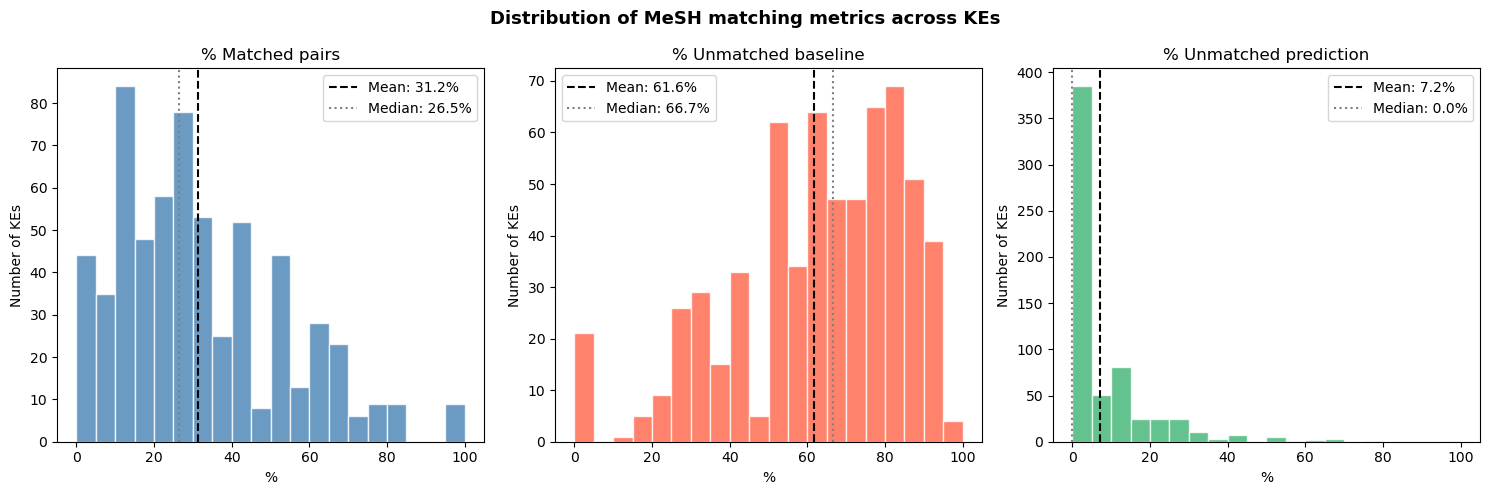

In [146]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("pct_matched",        "% Matched pairs",        "steelblue"),
    ("pct_unmatched_base", "% Unmatched baseline",   "tomato"),
    ("pct_unmatched_pred", "% Unmatched prediction", "mediumseagreen"),
]

for ax, (col, title, color) in zip(axes, metrics):
    data = df_per_ke_titles[col].dropna().values
    ax.hist(data, bins=20, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(data.mean(),   color="black", linestyle="--", label=f"Mean: {data.mean():.1f}%")
    ax.axvline(np.median(data), color="gray", linestyle=":",  label=f"Median: {np.median(data):.1f}%")
    ax.set_title(title)
    ax.set_xlabel("%")
    ax.set_ylabel("Number of KEs")
    ax.legend()

plt.suptitle("Distribution of MeSH matching metrics across KEs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

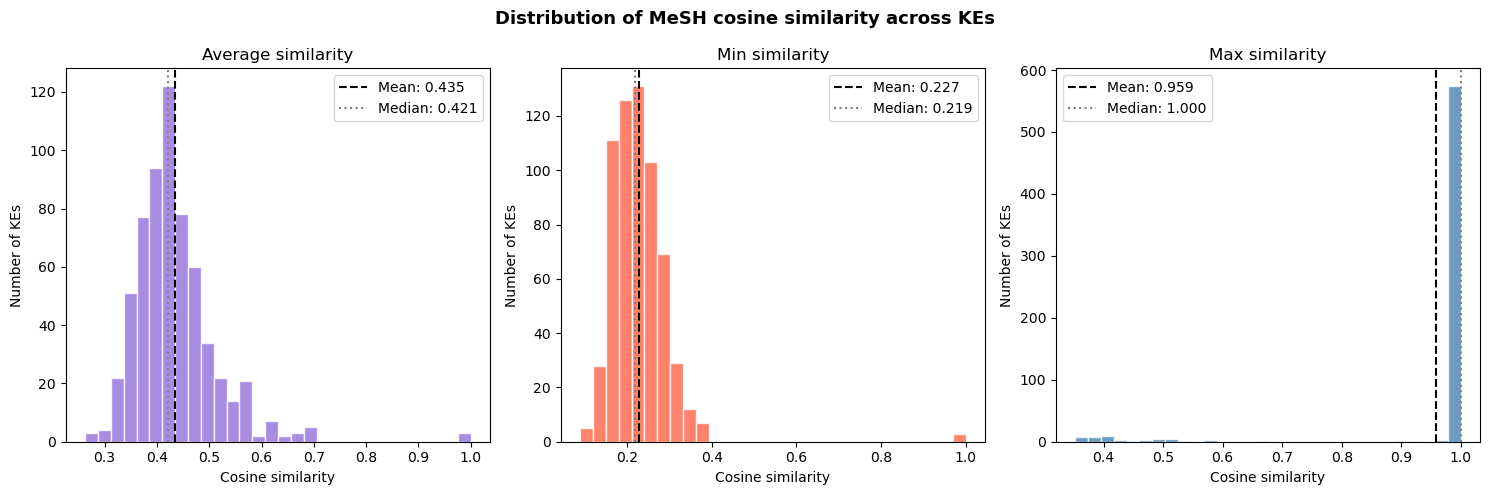

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("avg_similarity", "Average similarity", "mediumpurple"),
    ("min_similarity", "Min similarity",     "tomato"),
    ("max_similarity", "Max similarity",     "steelblue"),
]

for ax, (col, title, color) in zip(axes, metrics):
    data = df_per_ke_titles[col].dropna().values
    ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(data.mean(),       color="black", linestyle="--", label=f"Mean: {data.mean():.3f}")
    ax.axvline(np.median(data),   color="gray",  linestyle=":",  label=f"Median: {np.median(data):.3f}")
    ax.set_title(title)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Number of KEs")
    ax.legend()

plt.suptitle("Distribution of MeSH cosine similarity across KEs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [148]:
pos_tagging_allMiniLM = pd.read_csv("pos_tagging_sem_matching_allMiniLM.tsv", sep = "\t")
pos_tagging_allMiniLM["MESH_ID"] = pos_tagging_allMiniLM["MESH_ID"].str.split("/").str[-1]

In [149]:
df_per_ke_allMiniLM, summary_allMiniLM = evaluate_matching(indexing_results_dataframe, pos_tagging_allMiniLM)

print("=== Per-KE breakdown ===")
print(df_per_ke_allMiniLM.to_string())

print("\n=== Mean across all KEs ===")
print(summary_allMiniLM.to_string())

=== Per-KE breakdown ===
                                         n_matched_pairs  n_unmatched_base  n_unmatched_pred  total  avg_similarity  min_similarity  max_similarity  pct_matched  pct_unmatched_base  pct_unmatched_pred
KE_ID                                                                                                                                                                                                   
https://identifiers.org/aop.events/10                  6                 2                 4     12        0.396671        0.172290        1.000000        50.00               16.67               33.33
https://identifiers.org/aop.events/1000               10                 1                17     28        0.434089        0.199323        1.000000        35.71                3.57               60.71
https://identifiers.org/aop.events/1001                2                 7                 5     14        0.376272        0.164982        1.000000        14.29           

In [150]:
pos_tagging_biobert = pd.read_csv("pos_tagging_sem_matching_biobert.tsv", sep = "\t")
pos_tagging_biobert["MESH_ID"] = pos_tagging_biobert["MESH_ID"].str.split("/").str[-1]

In [151]:
df_per_ke_biobert, summary_biobert = evaluate_matching(indexing_results_dataframe, pos_tagging_biobert)

print("=== Per-KE breakdown ===")
print(df_per_ke_biobert.to_string())

print("\n=== Mean across all KEs ===")
print(summary_biobert.to_string())

=== Per-KE breakdown ===
                                         n_matched_pairs  n_unmatched_base  n_unmatched_pred  total  avg_similarity  min_similarity  max_similarity  pct_matched  pct_unmatched_base  pct_unmatched_pred
KE_ID                                                                                                                                                                                                   
https://identifiers.org/aop.events/10                  6                 2                 4     12        0.396117        0.172290        1.000000        50.00               16.67               33.33
https://identifiers.org/aop.events/1000               10                 1                16     27        0.445739        0.199323        1.000000        37.04                3.70               59.26
https://identifiers.org/aop.events/1001                3                 6                 5     14        0.388827        0.164982        1.000000        21.43           

In [152]:
indexing_titles_top40 = pd.read_csv("indexing_titles_results_scores_top40.tsv", sep = "\t")
indexing_titles_top40["MESH_ID"] = indexing_titles_top40["MESH_ID"].str.split("/").str[-1]

In [153]:
indexing_titles_top8 = (
    indexing_titles_top40
    .sort_values(["KE_ID", "SCORE"], ascending=[True, False])
    .groupby("KE_ID")
    .head(40)
    .reset_index(drop=True)
)

In [154]:
df_per_ke_titles_top8, summary_titles_top8 = evaluate_matching(indexing_results_dataframe, indexing_titles_top8)

print("=== Per-KE breakdown ===")
print(df_per_ke_titles_top8.to_string())

print("\n=== Mean across all KEs ===")
print(summary_titles_top8.to_string())

=== Per-KE breakdown ===
                                         n_matched_pairs  n_unmatched_base  n_unmatched_pred  total  avg_similarity  min_similarity  max_similarity  pct_matched  pct_unmatched_base  pct_unmatched_pred
KE_ID                                                                                                                                                                                                   
https://identifiers.org/aop.events/10                 12                 0                32     44        0.375862        0.138919        1.000000        27.27                0.00               72.73
https://identifiers.org/aop.events/1000                9                 0                35     44        0.354765        0.127675        1.000000        20.45                0.00               79.55
https://identifiers.org/aop.events/1001                7                 2                33     42        0.364044        0.140042        1.000000        16.67           

In [155]:
summaries_titles = {}

for top_n in range(1, 9):
    indexing_titles_topN = (
        indexing_titles_top40
        .sort_values(["KE_ID", "SCORE"], ascending=[True, False])
        .groupby("KE_ID")
        .head(top_n)
        .reset_index(drop=True)
    )

    _, summary = evaluate_matching(indexing_results_dataframe, indexing_titles_topN)
    summaries_titles[top_n] = summary

In [156]:
summaries_allMiniLM = {}

for top_n in range(1, 9):
    pos_tagging_allMiniLM_topN = (
        pos_tagging_allMiniLM
        .sort_values(["KE_ID", "SCORE"], ascending=[True, False])
        .groupby("KE_ID")
        .head(top_n)
        .reset_index(drop=True)
    )

    _, summary = evaluate_matching(indexing_results_dataframe, pos_tagging_allMiniLM_topN)
    summaries_allMiniLM[top_n] = summary

In [157]:
summaries_biobert = {}

for top_n in range(1, 9):
    pos_tagging_biobert_topN = (
        pos_tagging_biobert
        .sort_values(["KE_ID", "SCORE"], ascending=[True, False])
        .groupby("KE_ID")
        .head(top_n)
        .reset_index(drop=True)
    )

    _, summary = evaluate_matching(indexing_results_dataframe, pos_tagging_biobert_topN)
    summaries_biobert[top_n] = summary

In [158]:
# build combined summary
datasets = {
    "titles":    summaries_titles,
    "allMiniLM": summaries_allMiniLM,
    "biobert":   summaries_biobert,
}

records = []
for name, summaries in datasets.items():
    for top_n, summary in summaries.items():
        row = {"model": name, "top_n": top_n}
        row.update(summary)
        records.append(row)

df_all_summaries = pd.DataFrame(records).set_index(["model", "top_n"])
print(df_all_summaries.round(3).to_string())

                 mean_pct_matched  mean_pct_unmatched_baseline  mean_pct_unmatched_prediction  avg_similarity
model     top_n                                                                                              
titles    1                13.414                       83.728                          2.857           0.433
          2                25.806                       68.332                          5.863           0.436
          3                32.139                       57.490                         10.371           0.425
          4                36.203                       48.768                         15.029           0.419
          5                38.486                       41.911                         19.603           0.414
          6                39.153                       36.848                         23.999           0.408
          7                39.450                       32.502                         28.046           0.404
          

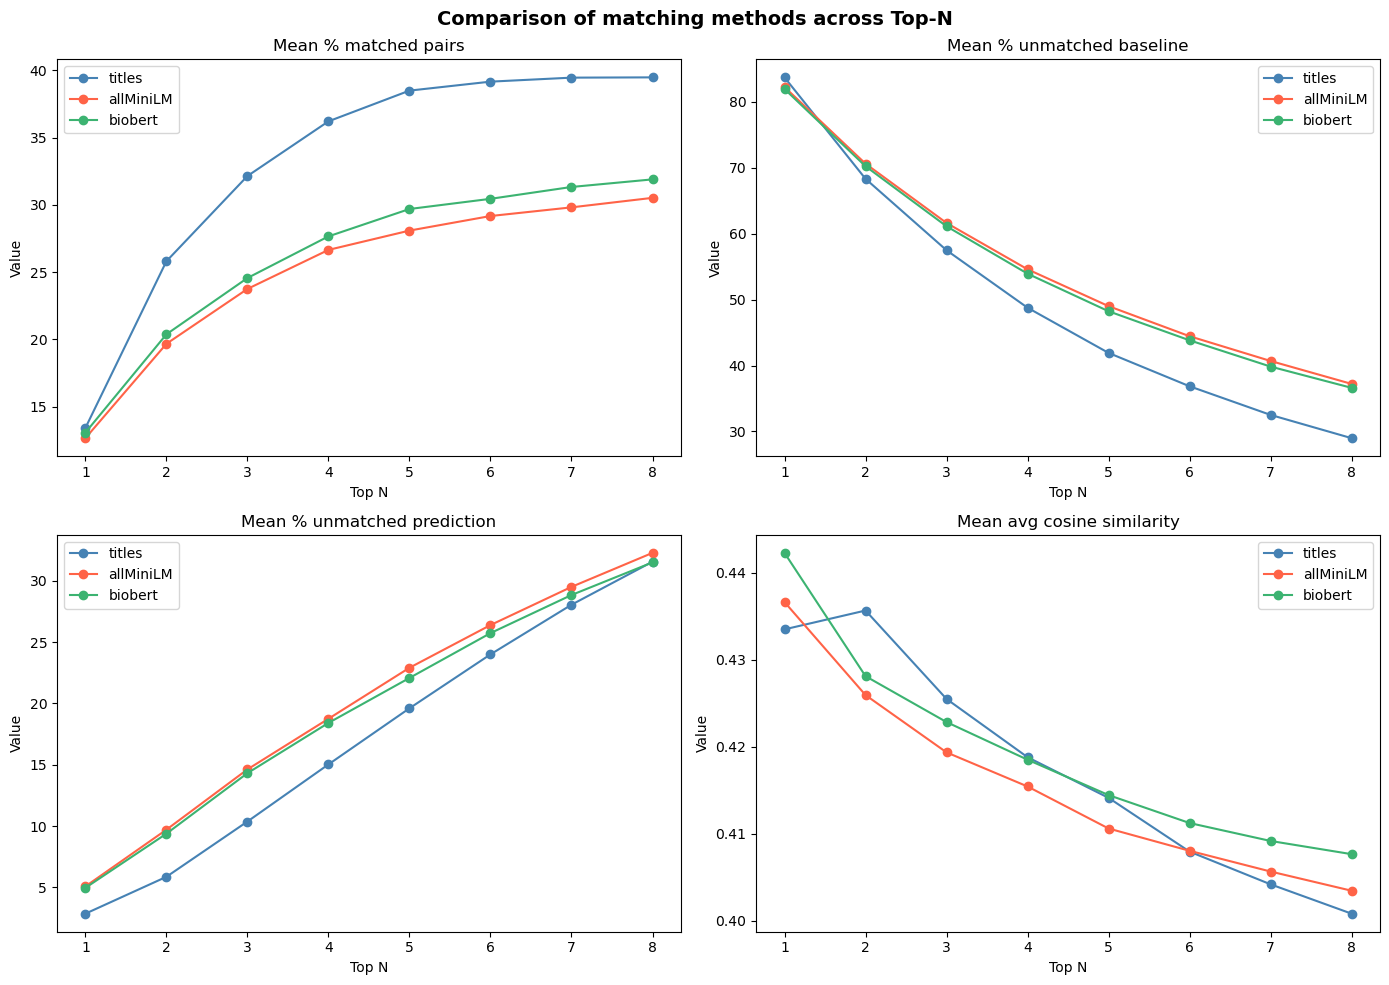

In [159]:
metrics = [
    ("mean_pct_matched",                "Mean % matched pairs"),
    ("mean_pct_unmatched_baseline",     "Mean % unmatched baseline"),
    ("mean_pct_unmatched_prediction",   "Mean % unmatched prediction"),
    ("avg_similarity",             "Mean avg cosine similarity"),
]

colors = {"titles": "steelblue", "allMiniLM": "tomato", "biobert": "mediumseagreen"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (metric, title) in zip(axes.flatten(), metrics):
    for model, color in colors.items():
        df_model = df_all_summaries.loc[model].sort_index()
        x = df_model.index.values
        y = df_model[metric].values
        ax.plot(x, y, marker="o", label=model, color=color)
    ax.set_title(title)
    ax.set_xlabel("Top N")
    ax.set_ylabel("Value")
    ax.set_xticks(range(1, 9))
    ax.legend()

plt.suptitle("Comparison of matching methods across Top-N", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top N based on drop in score

In [160]:
pos_tagging_allMiniLM_top50 = pd.read_csv('pos_tagging_sem_matching_allMiniLM_top50.tsv',sep = '\t')

In [198]:
pos_tagging_allMiniLM_top50["MESH_ID"] = pos_tagging_allMiniLM_top50["MESH_ID"].str.split("/").str[-1]

In [182]:
def compute_all_drops(df):
    drops = []
    for ke_id, group in df.groupby("KE_ID"):
        group = group.sort_values("SCORE", ascending=False).reset_index(drop=True)
        diffs = group["SCORE"].diff(-1).dropna()
        drops.extend(diffs.tolist())
    return pd.Series(drops)

all_drops = compute_all_drops(pos_tagging_allMiniLM_top50)
print(all_drops.describe())

count    45478.000000
mean         0.005025
std          0.016595
min          0.000000
25%          0.000514
50%          0.001412
75%          0.003637
max          0.481681
dtype: float64


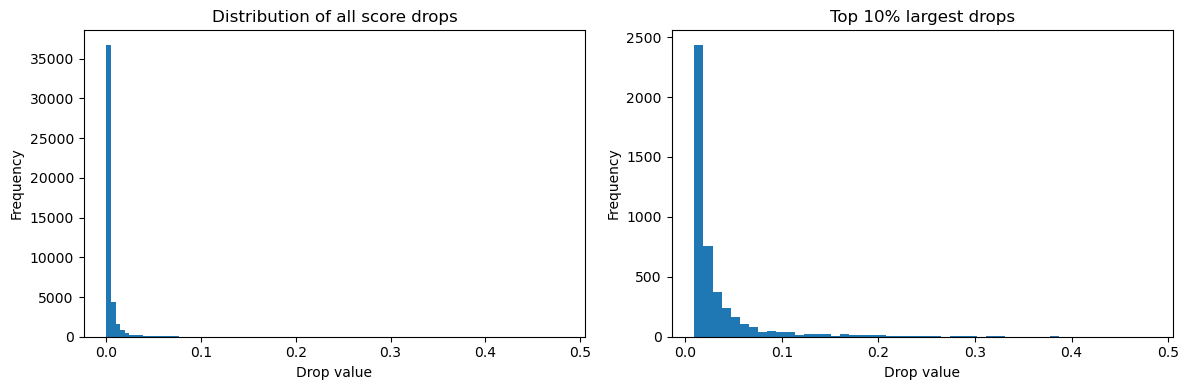

In [183]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution
all_drops.plot(kind="hist", bins=100, ax=axes[0])
axes[0].set_title("Distribution of all score drops")
axes[0].set_xlabel("Drop value")

# Zoom in on the tail (the "big" drops)
all_drops[all_drops > all_drops.quantile(0.90)].plot(kind="hist", bins=50, ax=axes[1])
axes[1].set_title("Top 10% largest drops")
axes[1].set_xlabel("Drop value")

plt.tight_layout()
plt.show()

In [189]:
def filter_score_drop(df, drop_threshold, min_matches, max_matches = 40) :
    results = []

    for ke_id, group in df.groupby("KE_ID") :
        group = group.sort_values("SCORE", ascending = False).reset_index(drop = True)
        score_drops = group["SCORE"].diff(-1)
        cutoff = None
        for i, drop in score_drops.items() :
            if i < min_matches - 1 :
                continue # keep min number of matches always
            if pd.notna(drop) and drop >= drop_threshold :
                cutoff = i + 1 # keep all matches in rows 0 -> i
                break
        if cutoff is None : 
            cutoff = len(group)
        
        cutoff = min(cutoff, max_matches) # if no drop is found, keep up to max_matches matches
        
        results.append(group.iloc[:cutoff])
    
    return pd.concat(results, ignore_index = True)

In [190]:
for threshold in [0.05, 0.10, 0.15, 0.20]:
    filtered = filter_score_drop(pos_tagging_allMiniLM_top50, drop_threshold=threshold, min_matches=1, max_matches= 40)
    counts = filtered.groupby("KE_ID")["MESH_ID"].count()
    print(f"threshold={threshold:.2f} → median matches: {counts.median():.1f}, mean: {counts.mean():.1f}, max: {counts.max()}")

threshold=0.05 → median matches: 1.0, mean: 13.1, max: 40
threshold=0.10 → median matches: 40.0, mean: 24.5, max: 40
threshold=0.15 → median matches: 40.0, mean: 30.9, max: 40
threshold=0.20 → median matches: 40.0, mean: 35.4, max: 40


In [193]:
for threshold in [0.01, 0.02, 0.03, 0.04, 0.05]:
    filtered = filter_score_drop(pos_tagging_allMiniLM_top50, drop_threshold=threshold, min_matches=1, max_matches= 40)
    counts = filtered.groupby("KE_ID")["MESH_ID"].count()
    print(f"threshold={threshold:.2f} → median matches: {counts.median():.1f}, mean: {counts.mean():.1f}, max: {counts.max()}")

threshold=0.01 → median matches: 1.0, mean: 1.4, max: 40
threshold=0.02 → median matches: 1.0, mean: 3.6, max: 40
threshold=0.03 → median matches: 1.0, mean: 6.5, max: 40
threshold=0.04 → median matches: 1.0, mean: 9.7, max: 40
threshold=0.05 → median matches: 1.0, mean: 13.1, max: 40


In [199]:
pos_tagging_allMiniLM_drop = filter_score_drop(
    pos_tagging_allMiniLM_top50,
    drop_threshold = 0.04,
    min_matches = 1,
    max_matches = 40
)

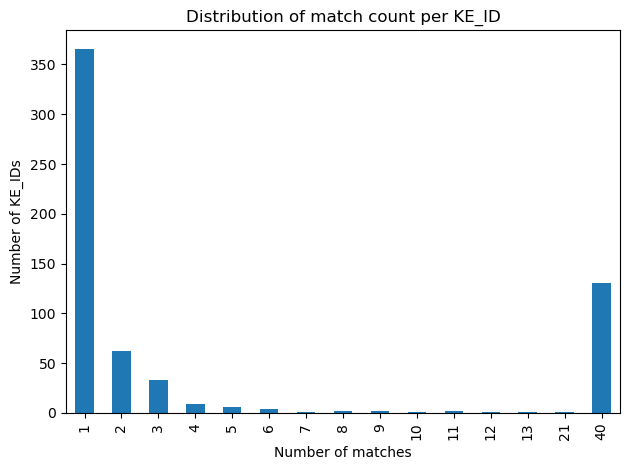

count    622.000000
mean       9.707395
std       15.735881
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max       40.000000
Name: MESH_ID, dtype: float64


In [200]:
# Count matches per KE_ID
match_counts = pos_tagging_allMiniLM_drop.groupby("KE_ID")["MESH_ID"].count()

# Plot
match_counts.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of matches")
plt.ylabel("Number of KE_IDs")
plt.title("Distribution of match count per KE_ID")
plt.tight_layout()
plt.show()

# Summary stats
print(match_counts.describe())

In [201]:
df_per_ke_pos_tagging_allMiniLM_drop, summary_pos_tagging_allMiniLM_drop = evaluate_matching(indexing_results_dataframe, pos_tagging_allMiniLM_drop)

print("=== Per-KE breakdown ===")
print(df_per_ke_pos_tagging_allMiniLM_drop.to_string())

print("\n=== Mean across all KEs ===")
print(summary_pos_tagging_allMiniLM_drop.to_string())

=== Per-KE breakdown ===
                                         n_matched_pairs  n_unmatched_base  n_unmatched_pred  total  avg_similarity  min_similarity  max_similarity  pct_matched  pct_unmatched_base  pct_unmatched_pred
KE_ID                                                                                                                                                                                                   
https://identifiers.org/aop.events/10                  1                 7                 0      8        0.411457        0.233143        1.000000        12.50               87.50                0.00
https://identifiers.org/aop.events/1000                4                 3                 0      7        0.649931        0.199323        0.993813        57.14               42.86                0.00
https://identifiers.org/aop.events/1001                8                 3                30     41        0.388007        0.124841        1.000000        19.51           

In [202]:
pos_tagging_biobert_top50 = pd.read_csv('pos_tagging_sem_matching_biobert_top50.tsv',sep = '\t')

In [203]:
pos_tagging_biobert_top50["MESH_ID"] = pos_tagging_biobert_top50["MESH_ID"].str.split("/").str[-1]

In [204]:
for threshold in [0.05, 0.10, 0.15, 0.20]:
    filtered = filter_score_drop(pos_tagging_biobert_top50, drop_threshold=threshold, min_matches=1, max_matches= 40)
    counts = filtered.groupby("KE_ID")["MESH_ID"].count()
    print(f"threshold={threshold:.2f} → median matches: {counts.median():.1f}, mean: {counts.mean():.1f}, max: {counts.max()}")

threshold=0.05 → median matches: 1.0, mean: 14.4, max: 40
threshold=0.10 → median matches: 40.0, mean: 26.4, max: 40
threshold=0.15 → median matches: 40.0, mean: 32.8, max: 40
threshold=0.20 → median matches: 40.0, mean: 36.1, max: 40


In [205]:
for threshold in [0.01, 0.02, 0.03, 0.04, 0.05]:
    filtered = filter_score_drop(pos_tagging_biobert_top50, drop_threshold=threshold, min_matches=1, max_matches= 40)
    counts = filtered.groupby("KE_ID")["MESH_ID"].count()
    print(f"threshold={threshold:.2f} → median matches: {counts.median():.1f}, mean: {counts.mean():.1f}, max: {counts.max()}")

threshold=0.01 → median matches: 1.0, mean: 1.5, max: 40
threshold=0.02 → median matches: 1.0, mean: 3.3, max: 40
threshold=0.03 → median matches: 1.0, mean: 6.2, max: 40
threshold=0.04 → median matches: 1.0, mean: 10.6, max: 40
threshold=0.05 → median matches: 1.0, mean: 14.4, max: 40


In [206]:
pos_tagging_biobert_drop = filter_score_drop(
    pos_tagging_biobert_top50,
    drop_threshold = 0.04,
    min_matches = 1,
    max_matches = 40
)

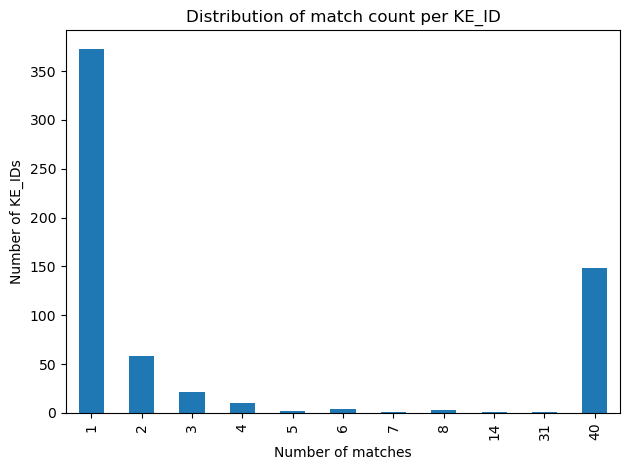

count    622.000000
mean      10.646302
std       16.489209
min        1.000000
25%        1.000000
50%        1.000000
75%        6.000000
max       40.000000
Name: MESH_ID, dtype: float64


In [207]:
# Count matches per KE_ID
match_counts = pos_tagging_biobert_drop.groupby("KE_ID")["MESH_ID"].count()

# Plot
match_counts.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of matches")
plt.ylabel("Number of KE_IDs")
plt.title("Distribution of match count per KE_ID")
plt.tight_layout()
plt.show()

# Summary stats
print(match_counts.describe())

In [208]:
df_per_ke_pos_tagging_biobert_drop, summary_pos_tagging_biobert_drop = evaluate_matching(indexing_results_dataframe, pos_tagging_biobert_drop)

print("=== Per-KE breakdown ===")
print(df_per_ke_pos_tagging_biobert_drop.to_string())

print("\n=== Mean across all KEs ===")
print(summary_pos_tagging_biobert_drop.to_string())

=== Per-KE breakdown ===
                                         n_matched_pairs  n_unmatched_base  n_unmatched_pred  total  avg_similarity  min_similarity  max_similarity  pct_matched  pct_unmatched_base  pct_unmatched_pred
KE_ID                                                                                                                                                                                                   
https://identifiers.org/aop.events/10                  1                 7                 0      8        0.411457        0.233143        1.000000        12.50               87.50                0.00
https://identifiers.org/aop.events/1000                1                 4                 0      5        0.477420        0.224299        0.686657        20.00               80.00                0.00
https://identifiers.org/aop.events/1001                0                 9                 1     10        0.359097        0.255180        0.421802         0.00           

In [210]:
summaries_allMiniLM_drop = {}

for threshold in [0.01, 0.02, 0.03, 0.04, 0.05]:
    filtered = filter_score_drop(
        pos_tagging_allMiniLM_top50, 
        drop_threshold = threshold, 
        min_matches = 1, 
        max_matches = 40
    )

    _, summary = evaluate_matching(indexing_results_dataframe, filtered)
    summaries_allMiniLM_drop[threshold] = summary

In [211]:
summaries_biobert_drop = {}

for threshold in [0.01, 0.02, 0.03, 0.04, 0.05]:
    filtered = filter_score_drop(
        pos_tagging_biobert_top50, 
        drop_threshold = threshold, 
        min_matches = 1, 
        max_matches = 40
    )

    _, summary = evaluate_matching(indexing_results_dataframe, filtered)
    summaries_biobert_drop[threshold] = summary

In [215]:
# build combined summary
datasets = {
    "allMiniLM": summaries_allMiniLM_drop,
    "biobert":   summaries_biobert_drop,
}

records = []
for name, summaries in datasets.items():
    for threshold, summary in summaries.items():
        row = {"model": name, "threshold": threshold}
        row.update(summary)
        records.append(row)

df_all_summaries = pd.DataFrame(records).set_index(["model", "threshold"])
print(df_all_summaries.round(3).to_string())

                     mean_pct_matched  mean_pct_unmatched_baseline  mean_pct_unmatched_prediction  avg_similarity
model     threshold                                                                                              
allMiniLM 0.01                 13.851                       79.483                          6.666           0.436
          0.02                 15.326                       73.956                         10.718           0.436
          0.03                 16.375                       68.262                         15.363           0.434
          0.04                 17.888                       62.085                         20.027           0.432
          0.05                 18.373                       56.157                         25.470           0.429
biobert   0.01                 14.526                       79.421                          6.053           0.441
          0.02                 15.698                       74.912                      

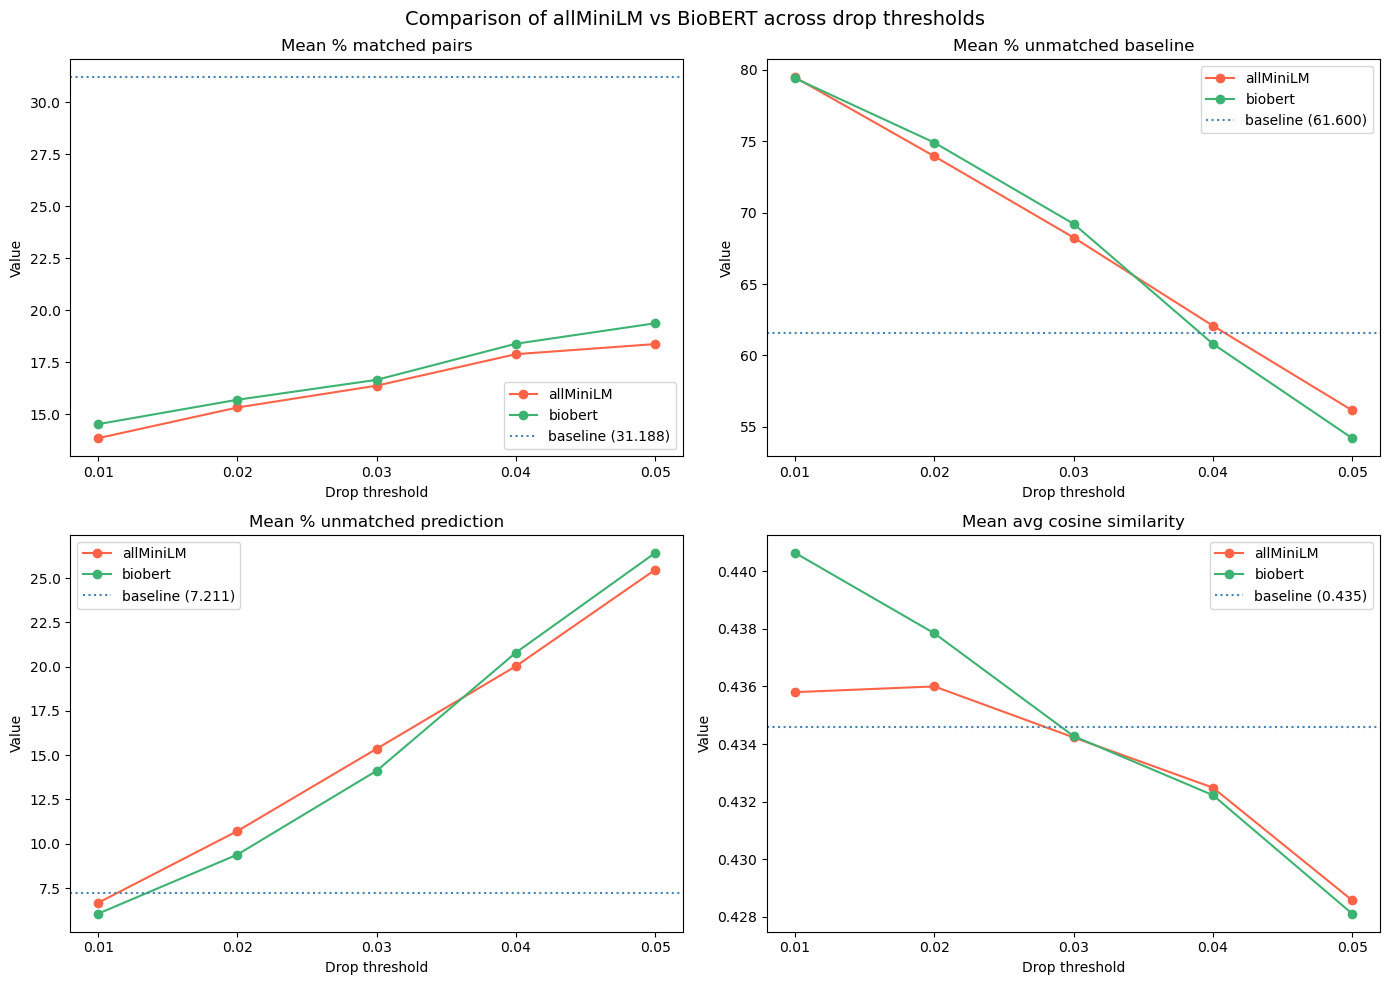

In [219]:
metrics = [
    ("mean_pct_matched",                "Mean % matched pairs"),
    ("mean_pct_unmatched_baseline",     "Mean % unmatched baseline"),
    ("mean_pct_unmatched_prediction",   "Mean % unmatched prediction"),
    ("avg_similarity",                  "Mean avg cosine similarity"),
]

baselines = {
    "mean_pct_matched":              31.188498,
    "mean_pct_unmatched_baseline":   61.600208,
    "mean_pct_unmatched_prediction":  7.211470,
    "avg_similarity":                 0.434580,
}


styles = {
    "allMiniLM": {"color": "tomato", "linestyle": "-",  "marker": "o"},
    "biobert":   {"color": "mediumseagreen", "linestyle": "-",  "marker": "o"},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (metric, title) in zip(axes.flatten(), metrics):
    for model, style in styles.items():
        df_model = df_all_summaries.loc[model].sort_index()
        ax.plot(
            df_model.index.values,
            df_model[metric].values,
            label=model,
            **style
        )
    ax.axhline(
        y=baselines[metric],
        color="steelblue", linestyle=":", linewidth=1.5,
        label=f"baseline ({baselines[metric]:.3f})"
    )
    ax.set_title(title)
    ax.set_xlabel("Drop threshold")
    ax.set_ylabel("Value")
    ax.set_xticks(df_all_summaries.loc["allMiniLM"].sort_index().index)
    ax.legend()

plt.suptitle("Comparison of allMiniLM vs BioBERT across drop thresholds", fontsize=14)
plt.tight_layout()
plt.show()